In [1]:
import gymnasium as gym
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append("..")

# Examine the enviornment

In [2]:
from rlc.envs.fogofwar import FogGridEnv
env = FogGridEnv(render_mode="rgb_array")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Render modes:      {env.metadata['render_modes']}")

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}  (row={obs // env.width}, col={obs % env.width})")

Observation space: Discrete(64)
Action space:      Discrete(4)
Render modes:      ['rgb_array']
Initial observation: 0  (row=0, col=0)


## Defining a fixed map layout for experimentation

In [4]:
env = FogGridEnv(
    height=24,
    width=24,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.08,
    trap_density=0.05,
)

env.reset(seed = 41)

env.print_map()

A . . . X . . . . . . . . . . . X . . O . . . .
. . O . . . . O . O . . . . . . . . . . . . . .
. . . O . . . . . . . . . . . O . O X . . . . .
O . . . . . . . . . . . . . . . . . . . . . . .
. O . . . . . . . . . . . . . . . . . . . O . .
. . . . . . . . . X . . . . . . . . O . . . . .
X . . . . . . . X . . . X . . . . . . . . . . .
. . X . X . . . . . . . . . . . . . O . . . . .
. O . O . . . . . . . . . . . . . . . . . . . .
O X O . . . O . . . X . . . . O . . O . . O . .
. . X . . . . . . . . X . . . . . . . . X . . O
. . . . . X . . . . . G . . . . . . . O . . . .
. . . . . . . . . X . . . . . . . X . . . . X .
. . . O . . . . . . . . . . . . . . . . X O . .
. . . . O . . . . . . . . . O . . . . . . . O .
X X . O . . . . . . . O . . . . . . . . . . . .
. . . . . . . . . . . X . . . . . . . . . . . .
O . . O . . . . . . . . . . . O . . . . . . . .
. . . . . . . . . X . O . . . . . . . . . . . .
. . . . . . . . . . . . . . . . . . . X . . . O
O . . . . O . . O X . . . . . . . . . . 

In [7]:
# based of a randomized map with seed = 41

fixed_obstacle_tiles = list(env.obstacle_tiles)

fixed_trap_tiles = list(env.trap_tiles)


# Experiments

## 1st Case
- Regular tabular Q-Learning with a fixed map layout. The most basic example to start defining the elements of the project.

In [26]:
# Two environment instances: one for training, one for evaluation.

from rlc.utils.training import train
from rlc.agents.q_learning import QLearningAgent
run_seeds = [42, 12, 33, 100, 133, 24, 99, 56, 1, 72]

In [27]:

print(len(run_seeds))
histories = []
results = []

map_h = 24
map_w = 24
goal_pos = (23,23)
for seed in run_seeds:
    train_env = FogGridEnv(
        height=map_h,
        width=map_w,
        start_pos=(0, 0),
        goal_pos=goal_pos,
        randomize_map=False,
        obstacle_tiles= fixed_obstacle_tiles,
        trap_tiles=fixed_trap_tiles,
        render_mode="rgb_array")

    eval_env = FogGridEnv(
        height=map_h,
        width=map_w,
        start_pos=(0, 0),
        goal_pos=goal_pos,
        randomize_map=False,
        obstacle_tiles= fixed_obstacle_tiles,
        trap_tiles=fixed_trap_tiles,
        render_mode="rgb_array")

    agent = QLearningAgent(
        n_states=train_env.observation_space.n,
        n_actions=train_env.action_space.n,
        alpha=0.1,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        seed= seed
    )

    history = train(
        agent,
        train_env,
        n_episodes=7500,
        max_steps_per_episode=400,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=200,
        progress=True,
        seed=seed
    )

    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    # no weights since no VFA
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                        history.eval_std_returns[-1], np.nan,history.eval_success_rate[-1] * 100,
                        history.eval_mean_len[-1], train_succ_rate * 100])

10


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    50.4
Final greedy evaluation return:    55.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 46.0 steps
Training success rate: 97.2%


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    49.4
Final greedy evaluation return:    55.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 46.0 steps
Training success rate: 97.5%


...

Final epsilon:                     0.050
Mean return, last 50 train eps:    49.5
Final greedy evaluation return:    55.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 46.0 steps
Training success rate: 97.3%


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    49.4
Final greedy evaluation return:    55.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 46.0 steps
Training success rate: 97.3%


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    50.3
Final greedy evaluation return:    55.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 46.0 steps
Training success rate: 97.4%


In [28]:
tql_df = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [ ]:
tql_df_.describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050000,0.000000,0.050000,0.050000,0.05,0.05,0.05
mean return last 50 eps,10.0,50.170000,0.646856,49.420000,49.640000,50.22,50.41,51.56
final greedy eval return_mean,10.0,55.000000,0.000000,55.000000,55.000000,55.00,55.00,55.00
final greedy eval return_std,10.0,0.000000,0.000000,0.000000,0.000000,0.00,0.00,0.00
weight matrix shape,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evaluation success rate,10.0,100.000000,0.000000,100.000000,100.000000,100.00,100.00,100.00
final mean episode length,10.0,46.000000,0.000000,46.000000,46.000000,46.00,46.00,46.00
training success rate,10.0,97.313333,0.100419,97.173333,97.253333,97.30,97.35,97.52


In [45]:
tql_df.to_excel("results_TQL_fixed_large.xlsx", index = False)

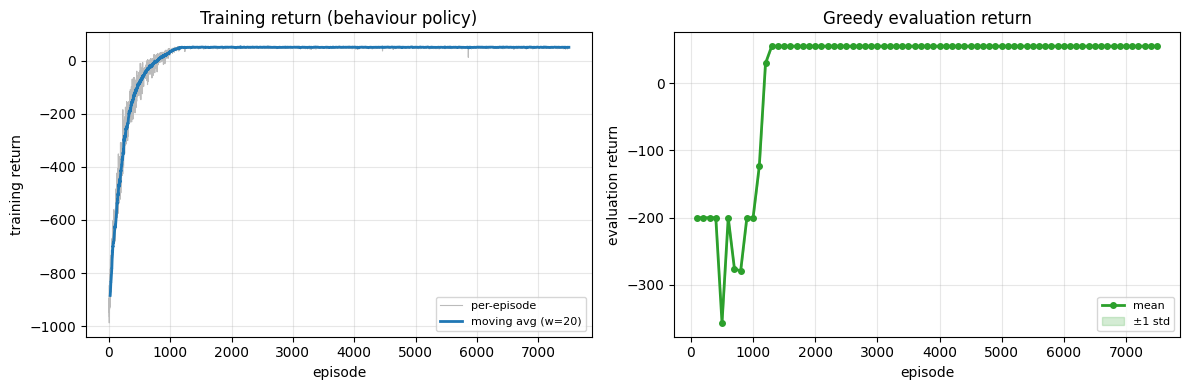

In [31]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()

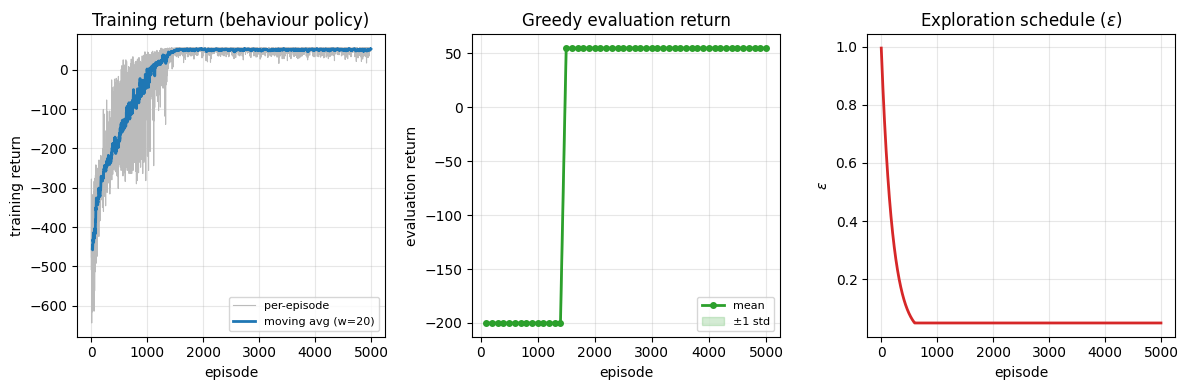

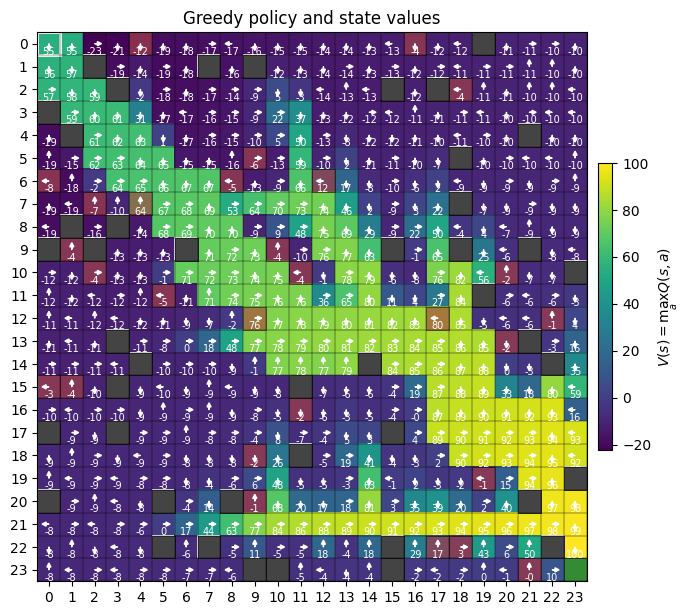

In [22]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## Variation of the 1st Case

- Same tabular Q-Learning model, but in this case we don't have a fixed map layout. Instead, each episode includes a completely new random layout.

In [32]:
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

In [33]:
results = []
histories = []

map_h = 24
goal_pos = (23,23)
for seed in run_seeds:

    # Two environment instances: one for training, one for evaluation.
    train_env = FogGridEnv(
        height=map_h,
        width=map_h,
        start_pos=(0, 0),
        goal_pos=goal_pos,
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        render_mode="rgb_array")

    eval_env = FogGridEnv(
        height=map_h,
        width=map_h,
        start_pos=(0, 0),
        goal_pos=goal_pos,
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        render_mode="rgb_array")

    agent = QLearningAgent(
        n_states=train_env.observation_space.n,
        n_actions=train_env.action_space.n,
        alpha=0.1,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        seed = seed
    )

    history = train(
        agent,
        train_env,
        n_episodes=7500,
        max_steps_per_episode=400,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=200,
        eval_map_setting="fixed",
        eval_map_seed= 123,
        progress=True,
        seed = seed
    )


    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                            history.eval_std_returns[-1], np.nan,history.eval_success_rate[-1] * 100,
                            history.eval_mean_len[-1], train_succ_rate * 100])

Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -357.7
Final greedy evaluation return:    -868.5 (std 313.7)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 83.6%


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -408.1
Final greedy evaluation return:    -694.6 (std 480.3)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 83.6%


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

...

Final epsilon:                     0.050
Mean return, last 50 train eps:    -371.5
Final greedy evaluation return:    -957.2 (std 105.8)
Final evaluation success rate: 1.0%
Final mean episode length: 198.5 steps
Training success rate: 83.5%


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -362.2
Final greedy evaluation return:    -849.4 (std 306.3)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 84.2%


Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -331.1
Final greedy evaluation return:    -863.6 (std 270.6)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 84.8%


In [34]:
random_tql_df = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [35]:
random_tql_df.describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050000,0.000000,0.050000,0.050000,0.05000,0.050000,0.050000
mean return last 50 eps,10.0,-354.414000,25.272728,-408.100000,-362.035000,-359.52000,-333.900000,-321.980000
final greedy eval return_mean,10.0,-808.171000,90.698843,-957.230000,-860.070000,-832.27000,-748.815000,-654.680000
final greedy eval return_std,10.0,334.359583,104.357446,105.837314,307.665555,326.21424,399.565317,480.319967
weight matrix shape,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evaluation success rate,10.0,0.100000,0.316228,0.000000,0.000000,0.00000,0.000000,1.000000
final mean episode length,10.0,199.848000,0.480666,198.480000,200.000000,200.00000,200.000000,200.000000
training success rate,10.0,83.920000,0.578325,83.200000,83.520000,83.72000,84.430000,84.773333


In [46]:
random_tql_df.to_excel("results_TQL_random_large.xlsx", index=False)

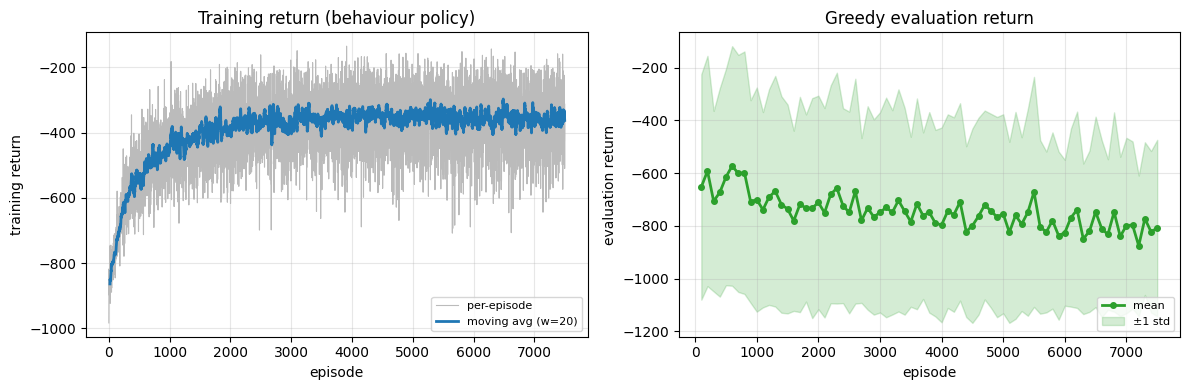

In [37]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()

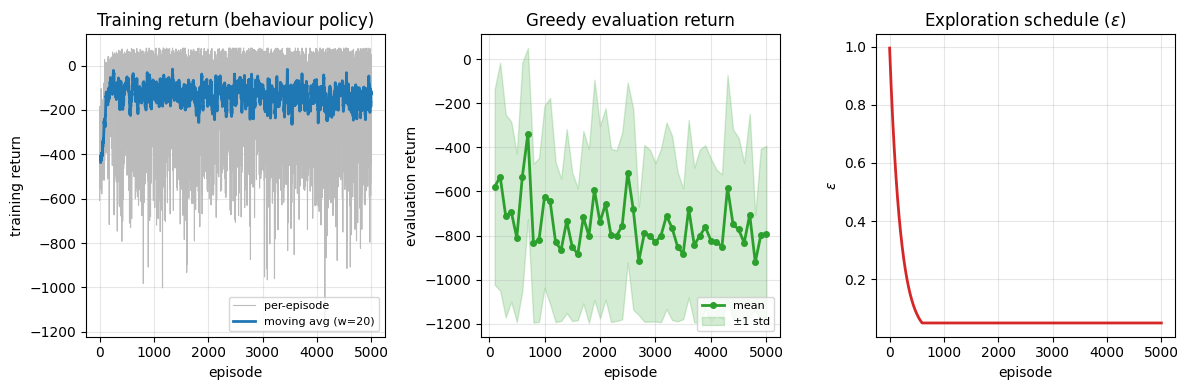

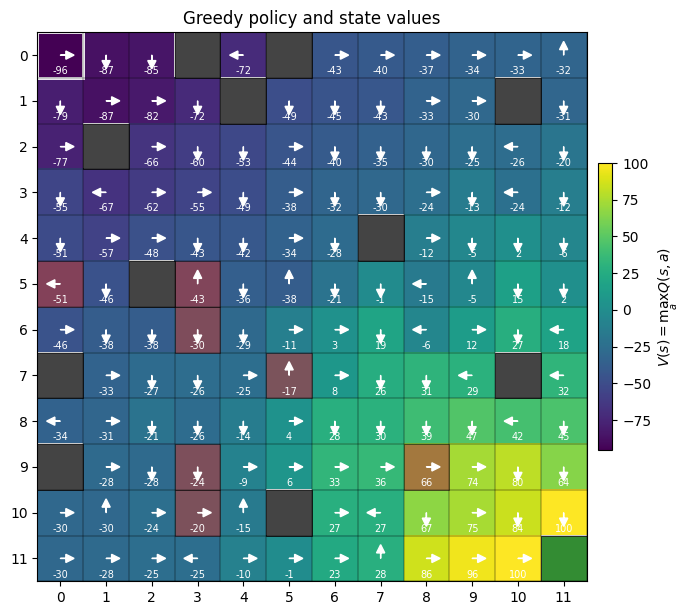

In [26]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## 2nd Case

- We create a local view for the agent, so it can lookup tiles that are 2 tiles from it.
- Each observation is now composed of the current position of the agent + the flattened local view.
- This, as the tabular model, will serve as the "index" in which Q-values will be updated for each agent+local view combination.

In [ ]:
from rlc.agents.q_learning_wlocal import LocalQLearningAgent
from rlc.utils.training import train


results = []
histories = []

for seed in run_seeds:

    # Two environment instances: one for training, one for evaluation.
    train_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view= True,
        render_mode="rgb_array")

    eval_env = FogGridEnv(
        height=12,
        width=12,
        start_pos=(0, 0),
        goal_pos=(11, 11),
        randomize_map=True,
        obstacle_density= 0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view= True,
        render_mode="rgb_array")

    agent = LocalQLearningAgent(
        n_actions=train_env.action_space.n,
        alpha=0.001,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        seed = seed
    )

    history = train(
        agent,
        train_env,
        n_episodes=5000,
        max_steps_per_episode=200,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=200,
        eval_map_setting="fixed",
        eval_map_seed= 123,
        progress=True,
        seed = seed
    )


    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                                history.eval_std_returns[-1], np.nan,history.eval_success_rate[-1] * 100,
                                history.eval_mean_len[-1], train_succ_rate * 100])

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -309.9
Final greedy evaluation return:    -314.9 (std 265.6)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.2%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -301.1
Final greedy evaluation return:    -306.3 (std 242.9)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.0%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

...

Final epsilon:                     0.050
Mean return, last 50 train eps:    -303.1
Final greedy evaluation return:    -300.2 (std 240.3)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.2%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -306.7
Final greedy evaluation return:    -410.1 (std 343.4)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.3%


Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -303.5
Final greedy evaluation return:    -310.3 (std 242.3)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps
Training success rate: 14.0%


In [28]:
indexed_random_tql_df = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [30]:
indexed_random_tql_df.describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050000,0.000000,0.050000,0.050000,0.050000,0.050000,0.050000
mean return last 50 eps,10.0,-301.972000,17.001391,-329.140000,-306.120000,-303.330000,-301.420000,-260.020000
final greedy eval return_mean,10.0,-314.718000,38.801228,-410.100000,-319.395000,-310.070000,-301.730000,-253.740000
final greedy eval return_std,10.0,251.911719,41.495284,173.692292,240.791857,248.250699,263.339468,343.396142
weight matrix shape,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
evaluation success rate,10.0,0.200000,0.632456,0.000000,0.000000,0.000000,0.000000,2.000000
final mean episode length,10.0,199.790000,0.664078,197.900000,200.000000,200.000000,200.000000,200.000000
training success rate,10.0,14.266000,0.466862,13.420000,14.030000,14.190000,14.575000,15.020000


In [ ]:
# indexed_random_tql_df.to_excel("results_IndexQL_random.xlsx", index=False)

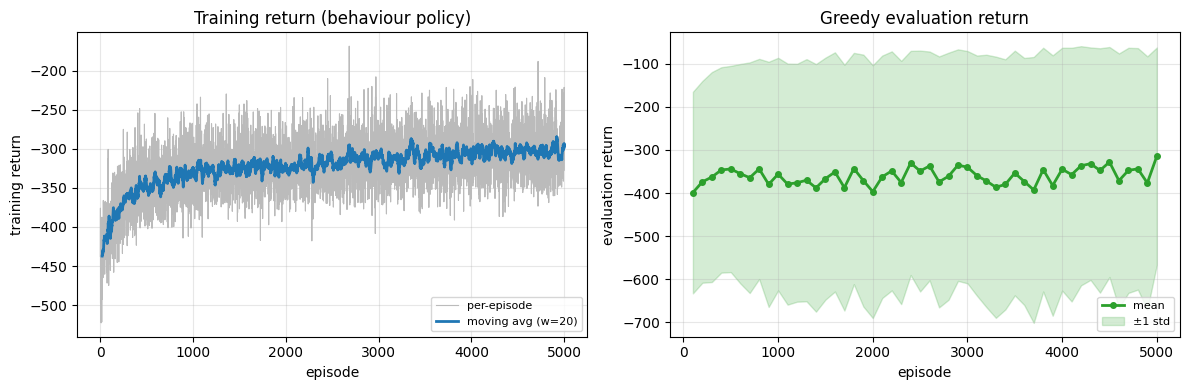

In [31]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()

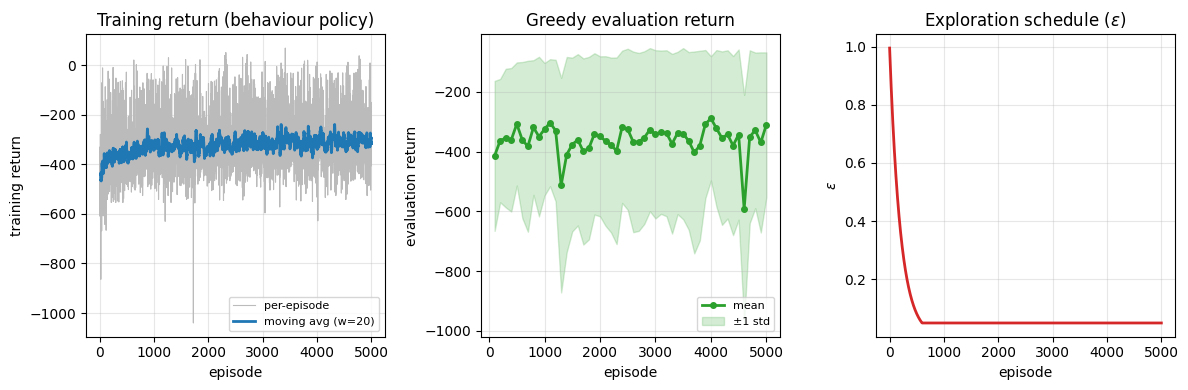

In [42]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()

# 3rd Case

- We include linera function approximation (LFA), creating a set of features that makes a better generalization in different scenarios.

In [47]:
from rlc.agents.q_learning_LFA import LFAQLearningAgent
from rlc.utils.features import LocalQuadrantFeatures
from rlc.utils.training import train

In [ ]:
results = []
histories = []

map_h = 24
map_w = 24
goal_pos = (23,23)

for seed in [42]:
    train_env = FogGridEnv(
        height=map_h,
        width=map_h,
        start_pos=(0, 0),
        goal_pos=goal_pos,
        randomize_map=True,
        obstacle_density=0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view=True,
        render_mode="rgb_array",
    )

    eval_env = FogGridEnv(
        height=map_h,
        width=map_h,
        start_pos=(0, 0),
        goal_pos=goal_pos,
        randomize_map=True,
        obstacle_density=0.08,
        trap_density=0.05,
        vision_radius=2,
        local_view=True,
        render_mode="rgb_array",
    )

    features = LocalQuadrantFeatures(
        height=train_env.height,
        width=train_env.width,
        vision_radius=2,
        exp_decay=1.0,
        exact_view=True
    )

    # better one: alpha = 0.005
    agent = LFAQLearningAgent(
        n_actions=train_env.action_space.n,
        feature_extractor=features,
        alpha=0.005,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.999,
        seed=seed
    )


    history = train(
        agent,
        train_env,
        n_episodes=7500,
        max_steps_per_episode=400,
        eval_every=100,
        eval_episodes=100,
        eval_env=eval_env,
        eval_max_steps=400,
        eval_map_setting="fixed",
        eval_map_seed= 123,
        seed=seed,
        progress=True,
    )
    
    print(f"Final epsilon:                     {agent.epsilon:.3f}")
    print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
    print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
        f"(std {history.eval_std_returns[-1]:.1f})")
    print("Weight matrix size:", agent.weights.shape)
    print("Weight norm:", np.linalg.norm(agent.weights))
    print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
    print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

    train_succ_rate = np.mean(history.eps_successess)
    histories.append(history)

    print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")
    
    
    results.append([agent.epsilon, np.mean(history.episode_returns[-50:]), history.eval_mean_returns[-1],
                    history.eval_std_returns[-1], agent.weights.shape,history.eval_success_rate[-1] * 100,
                    history.eval_mean_len[-1], train_succ_rate * 100])

Training:   0%|          | 0/7500 [00:00<?, ?ep/s]

KeyboardInterrupt: 

In [40]:
LFA_ql_df_24 = pd.DataFrame(results, columns = ["final epsilon", "mean return last 50 eps", "final greedy eval return_mean", 
                                 "final greedy eval return_std", "weight matrix shape", "evaluation success rate", 
                                 "final mean episode length", "training success rate"])

In [42]:
LFA_ql_df_24.to_excel("results_LFA_agent_24.xlsx", index = False)

In [43]:
LFA_ql_df_24.describe().T

,count,mean,std,min,25%,50%,75%,max
final epsilon,10.0,0.050000,0.000000,0.050000,0.050000,0.050000,0.050000,0.050000
mean return last 50 eps,10.0,-407.884000,17.519657,-423.800000,-415.490000,-411.940000,-408.295000,-362.940000
final greedy eval return_mean,10.0,-208.792000,2.504524,-215.920000,-208.000000,-208.000000,-208.000000,-208.000000
final greedy eval return_std,10.0,82.783239,10.069464,79.598995,79.598995,79.598995,79.598995,111.441436
evaluation success rate,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
final mean episode length,10.0,200.000000,0.000000,200.000000,200.000000,200.000000,200.000000,200.000000
training success rate,10.0,7.237333,0.822590,6.120000,6.650000,7.286667,7.630000,8.706667


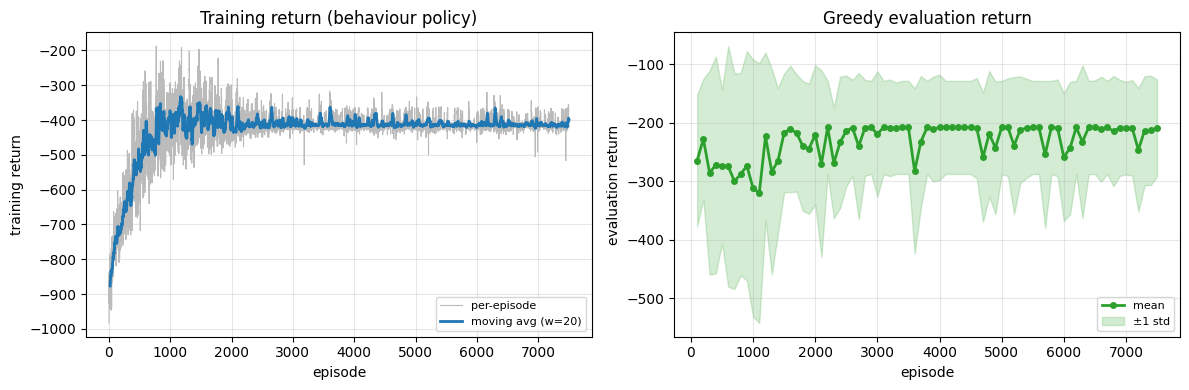

In [44]:
eps_returns = [x.episode_returns for x in histories]
eval_returns = [x.eval_episodes for x in histories]

eval_mean_returns = [x.eval_mean_returns for x in histories]
eval_std_returns = [x.eval_std_returns for x in histories]

smoothing_window = 20
fig, axes = plt.subplots(1, 2, figsize=(12,4))

ax = axes[0]
returns = np.asarray(np.mean(eps_returns, axis = 0), dtype=np.float64)

episodes = np.arange(1, len(returns) + 1)
ax.plot(episodes, returns, color="#bbbbbb", linewidth=0.8,
        label="per-episode")
if smoothing_window > 1 and len(returns) >= smoothing_window:
    smoothed = np.convolve(
        returns, np.ones(smoothing_window) / smoothing_window, mode="valid"
    )
    ax.plot(
        np.arange(smoothing_window, len(returns) + 1),
        smoothed,
        color="#1f77b4", linewidth=2.0,
        label=f"moving avg (w={smoothing_window})",
    )
ax.set_xlabel("episode")
ax.set_ylabel("training return")
ax.set_title("Training return (behaviour policy)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)


# --- evaluation return ------------------------------------------------
ax = axes[1]
if history.eval_episodes:
    ep = np.asarray(eval_returns[0])
    mean = np.asarray(np.mean(eval_mean_returns, axis =0))
    std = np.asarray(np.mean(eval_std_returns, axis =0))
    ax.plot(ep, mean, color="#2ca02c", linewidth=2.0, marker="o",
            markersize=4, label="mean")
    ax.fill_between(ep, mean - std, mean + std,
                    color="#2ca02c", alpha=0.2, label="±1 std")
    ax.legend(loc="lower right", fontsize=8)
else:
    ax.text(0.5, 0.5, "no evaluation data\n(set eval_every in train)",
            ha="center", va="center", transform=ax.transAxes,
            color="gray", fontsize=10)
ax.set_xlabel("episode")
ax.set_ylabel("evaluation return")
ax.set_title("Greedy evaluation return")
ax.grid(alpha=0.3)


fig.tight_layout()

plt.show()

In [27]:
final_returns = history.eval_map_returns[-1]
final_success = history.eval_map_success[-1]

In [28]:
for i, (ret, success) in enumerate(
    zip(final_returns, final_success)
):
    print(
        f"Map {i:3d}: "
        f"return={ret:7.1f}, "
        f"success={success}"
    )

Map   0: return= -950.0, success=False
Map   1: return= -940.0, success=False
Map   2: return=   79.0, success=True
Map   3: return= -944.0, success=False
Map   4: return= -952.0, success=False
Map   5: return=   65.0, success=True
Map   6: return= -958.0, success=False
Map   7: return= -932.0, success=False
Map   8: return= -956.0, success=False
Map   9: return=   65.0, success=True
Map  10: return= -924.0, success=False
Map  11: return= -956.0, success=False
Map  12: return= -936.0, success=False
Map  13: return= -952.0, success=False
Map  14: return= -944.0, success=False
Map  15: return=   79.0, success=True
Map  16: return=   51.0, success=True
Map  17: return=   65.0, success=True
Map  18: return= -940.0, success=False
Map  19: return= -952.0, success=False
Map  20: return= -964.0, success=False
Map  21: return= -936.0, success=False
Map  22: return= -952.0, success=False
Map  23: return= -962.0, success=False
Map  24: return= -946.0, success=False
Map  25: return= -952.0, succes

In [29]:
layout = history.eval_maps[53]

eval_env.randomize_map = False
eval_env.set_layout(layout)

obs, _ = eval_env.reset()

In [30]:
eval_env.print_map()

A . . . . . . . . . . .
. . . O . X . . X X . .
. . . . . . O . . X . .
. . . . . . . . . . . .
. . O X X . . O . . . .
. . . . . . . . O . . O
. . . . . . . . O . . O
. . . . . . . . . . . .
. . . . . X . . . . . .
. . . . . O . . . . . .
. O . . . . . . . . . .
. . . . . . . . . O . G


In [31]:
positions = []

for _ in range(200):
    positions.append(eval_env._agent_pos)

    action = agent.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, _ = eval_env.step(action)

    if terminated or truncated:
        break

print(positions)

[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (11, 1), (11, 2), (11, 3), (11, 4), (11, 5), (11, 6), (11, 7), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (11, 8), (

In [38]:
eval_env.print_map()

S . . . . . . . . . . .
. . . O . X . . X X . .
. . . . . . O . . X . .
. . . . . . . . . . . .
. . O X X . . O . . . .
. . . . . . . . O . . O
. . . . . . . . O . . O
. . . . . . . . . . . .
. . . . . X . . . . . .
. . . . . O . . . . . .
. O . . . . . . . . . .
. . . . . . . . . O . A


In [8]:
len(positions)

22

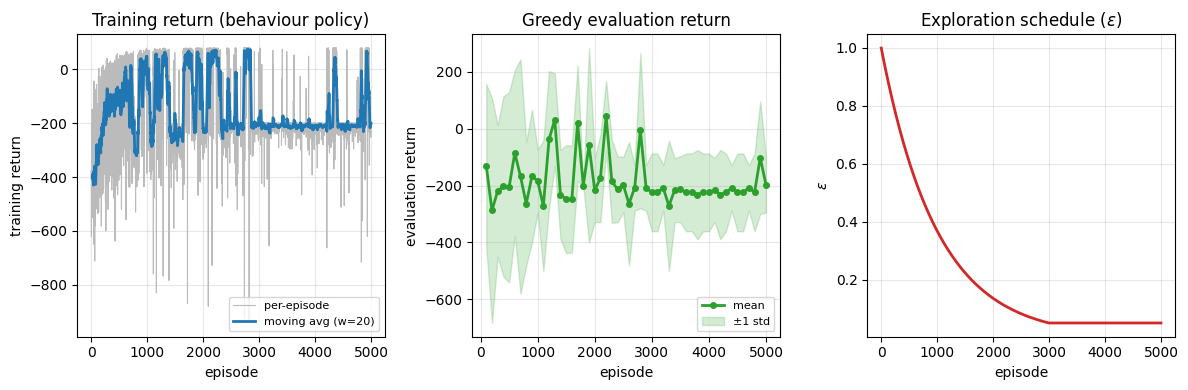

In [7]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()